
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.94      0.88     63844
           1       0.93      0.81      0.87     63844

    accuracy                           0.87    127688
   macro avg       0.88      0.87      0.87    127688
weighted avg       0.88      0.87      0.87    127688



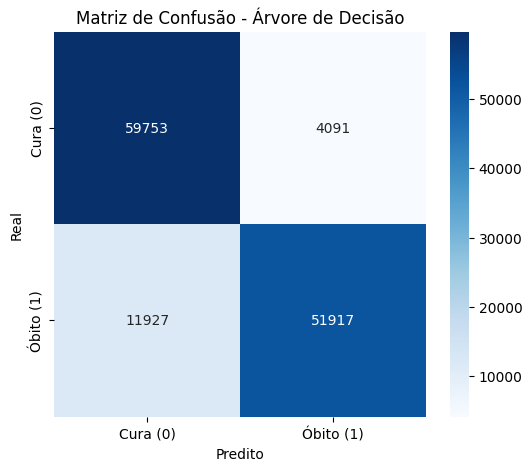

/tmp/ipython-input-4-3460602947.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=importancias, palette='viridis')


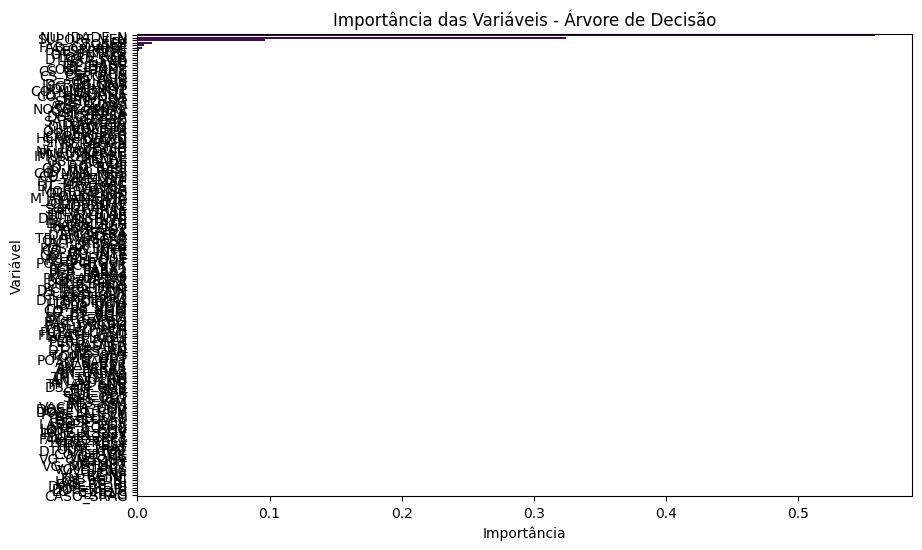


Importância das variáveis:
       Variável  Importância
11   NU_IDADE_N     0.558175
75   SUPORT_VEN     0.323857
72          UTI     0.096235
29        TOSSE     0.010841
155  FAB_COVREF     0.005354
..          ...          ...
181   DOSE_ADIC     0.000000
182   DOS_RE_BI     0.000000
183   LOTE_ADIC     0.000000
184       TABAG     0.000000
185   CASO_SRAG     0.000000

[186 rows x 2 columns]


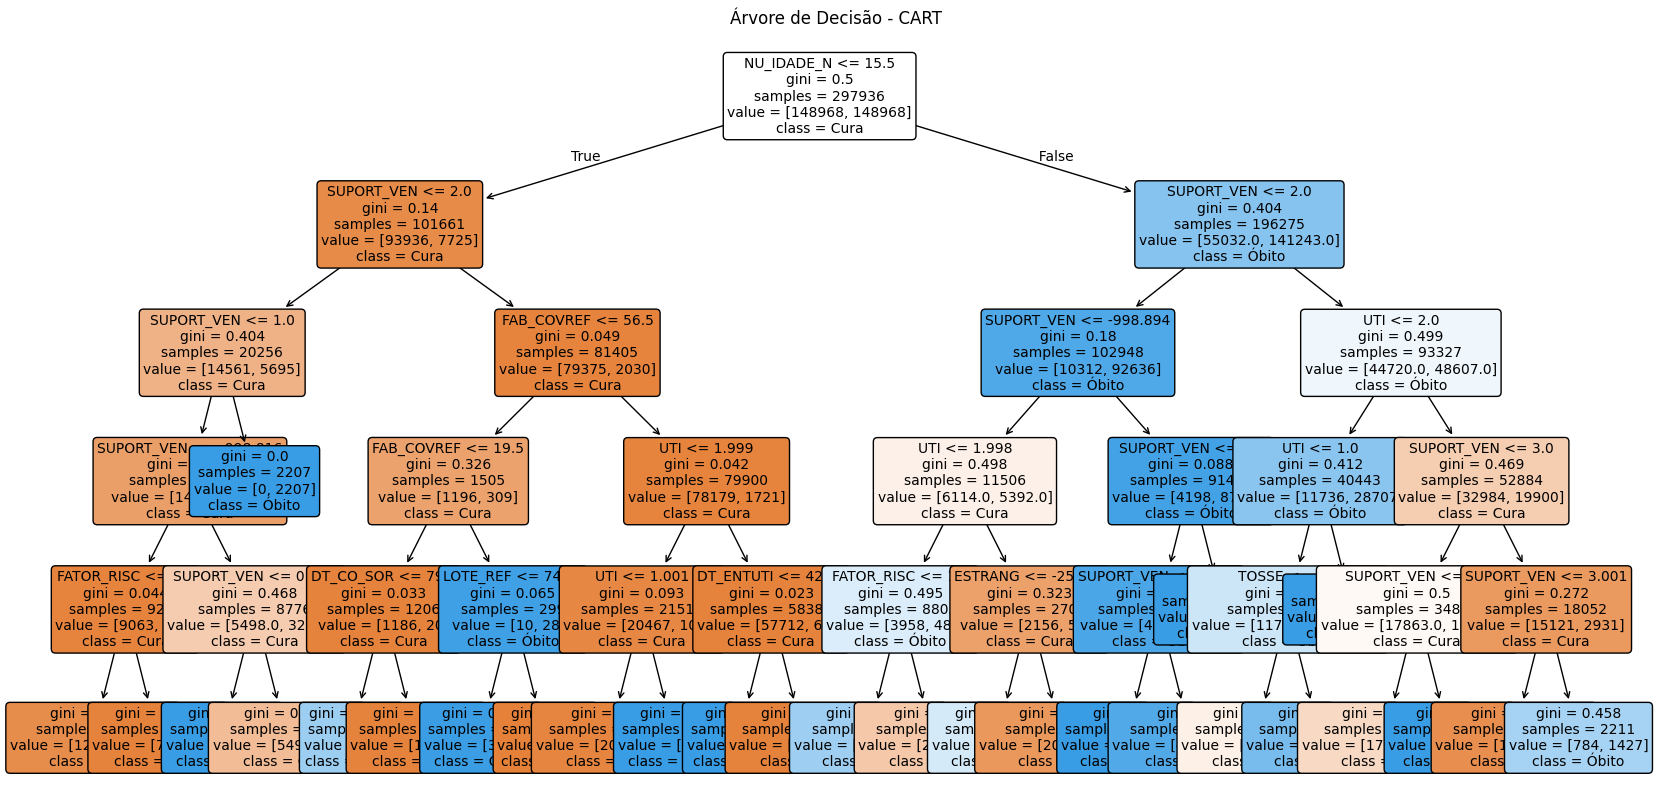


⏰ Tempo total de execução: 43.28 segundos


In [4]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import SMOTE

# Cronômetro
start_time = time.time()

#  1. Carregar os dados
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

#  2. Selecionar variável alvo e filtrar
df = df[df['EVOLUCAO'].isin([1, 2])].copy()
df['EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})  # 0 = Cura, 1 = Óbito

#  3. Selecionar colunas preditoras
# Remove 'EVOLUCAO' e colunas que não fazem sentido (ID's, datas, etc.)
colunas_remover = ['EVOLUCAO', 'DT_NOTIFIC', 'DT_INTERNA', 'DT_SIN_PRI', 'DT_EVOLUCA']  # adicione outras se necessário
variaveis = [col for col in df.columns if col not in colunas_remover]

X = df[variaveis].copy()
y = df['EVOLUCAO']

#  4. Converter variáveis categóricas em numéricas
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna('Desconhecido')
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    else:
        X[col] = pd.to_numeric(X[col], errors='coerce')

#  5. Tratar valores ausentes
X = X.fillna(-999)  # ou outra estratégia

#  6. Balanceamento
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

#  7. Treinamento do modelo
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

clf = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=5)
clf.fit(X_train, y_train)

#  8. Avaliação
y_pred = clf.predict(X_test)
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

#  9. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cura (0)', 'Óbito (1)'],
            yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()

#  10. Importância das variáveis
importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': clf.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importância', y='Variável', data=importancias, palette='viridis')
plt.title('Importância das Variáveis - Árvore de Decisão')
plt.show()

print("\nImportância das variáveis:")
print(importancias)

# 11. Árvore de Decisão
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['Cura', 'Óbito'],
          filled=True, rounded=True, fontsize=10)
plt.title("Árvore de Decisão - CART")
plt.show()

#  Tempo total
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\n⏰ Tempo total de execução: {elapsed_time:.2f} segundos")



✅ Top variáveis mais importantes para prever a EVOLUCAO:

  Variável Importância (%)
NU_IDADE_N          55.82%
SUPORT_VEN          32.39%
       UTI           9.62%
     TOSSE           1.08%
FAB_COVREF           0.54%
FATOR_RISC           0.39%
   ESTRANG           0.10%
 DT_ENTUTI           0.04%
  LOTE_REF           0.01%
 DT_CO_SOR           0.01%
   CS_SEXO           0.00%
   DT_NASC           0.00%
  TP_IDADE           0.00%
 COD_IDADE           0.00%
CS_GESTANT           0.00%
   CS_RACA           0.00%
CS_ESCOL_N           0.00%
   ID_PAIS           0.00%
   CO_PAIS           0.00%
ID_REGIONA           0.00%


/tmp/ipython-input-6-3582411223.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importância (%)', y='Variável', data=importancias_top, palette='viridis')


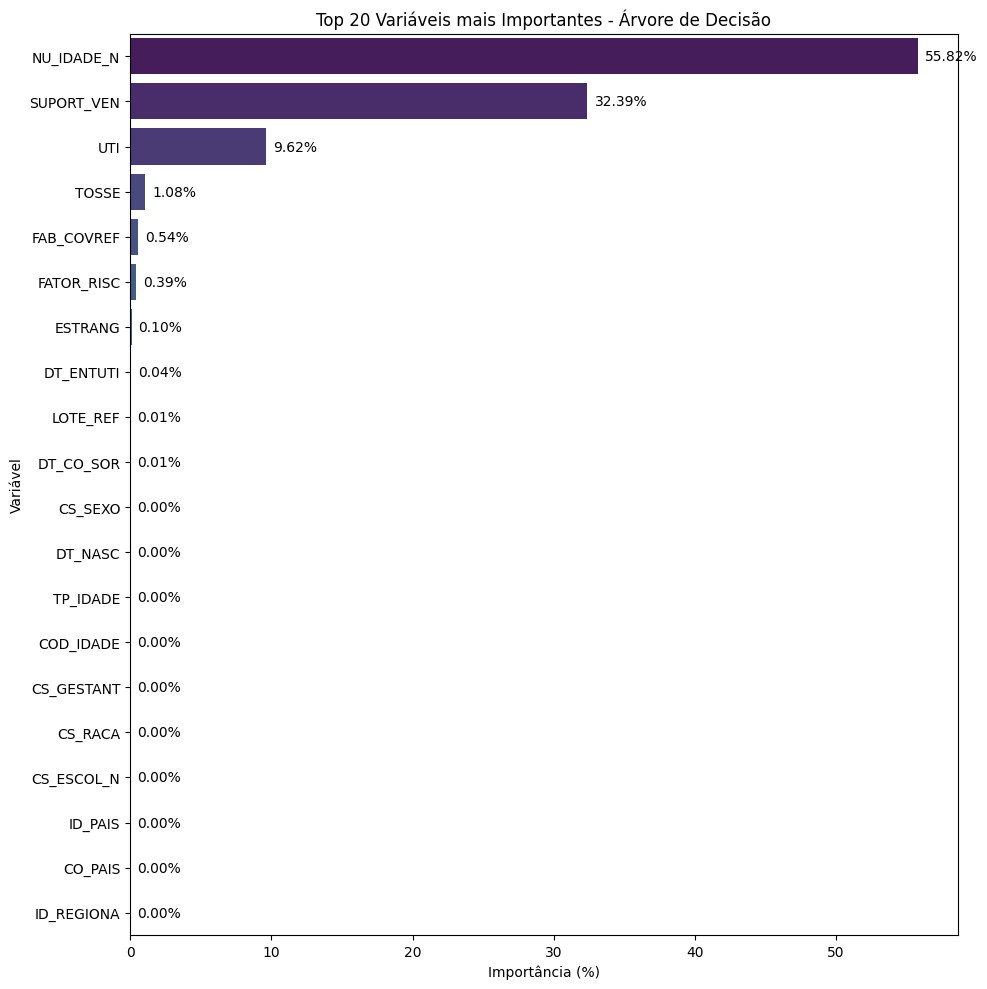

In [6]:
# Mostrar top N variáveis mais importantes
top_n = 20

importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': clf.feature_importances_
})

# Normaliza para porcentagem
importancias['Importância (%)'] = 100 * importancias['Importância'] / importancias['Importância'].sum()

# Ordena
importancias = importancias.sort_values(by='Importância (%)', ascending=False)

# Filtra apenas as mais importantes
importancias_top = importancias.head(top_n)

# Tabela bonita
print("\n✅ Top variáveis mais importantes para prever a EVOLUCAO:\n")
print(importancias_top[['Variável', 'Importância (%)']].to_string(index=False, formatters={'Importância (%)': '{:,.2f}%'.format}))

# Gráfico horizontal com porcentagens
plt.figure(figsize=(10, 0.5 * top_n))
ax = sns.barplot(x='Importância (%)', y='Variável', data=importancias_top, palette='viridis')

# Adiciona rótulos com porcentagem em cada barra
for i, (valor, nome) in enumerate(zip(importancias_top['Importância (%)'], importancias_top['Variável'])):
    ax.text(valor + 0.5, i, f'{valor:.2f}%', va='center')

plt.title(f'Top {top_n} Variáveis mais Importantes - Árvore de Decisão')
plt.xlabel('Importância (%)')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()
